In [1]:
import pandas as pd

golden = pd.read_csv("../data/golden_set.csv")

# Keep only tweets you've labeled
golden = golden[golden["intent"].notna() & (golden["intent"] != "")]

print("Labeled tweets:", len(golden))
golden[["text", "intent"]].head()

Labeled tweets: 150


,text,intent
0,@SpotifyCares Best response ever! Me @ the use...,General Inquiry
1,@SpotifyCares Spotify Student + Hulu renews to...,Premium Billing
2,@SpotifyCares I just dumped the whole thing. I...,Playback Issues
3,"@SpotifyCares my band's ""related artists"" sect...",General Inquiry
4,"@SpotifyCares Uh no....that""s not an answer. G...",General Inquiry


In [2]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    stop_words="english",
    max_features=1000
)

X = vectorizer.fit_transform(golden["text"])
y = golden["intent"]

print("Feature matrix:", X.shape)

Feature matrix: (150, 687)


In [3]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train:", X_train.shape[0])
print("Test:", X_test.shape[0])

Train: 120
Test: 30


In [4]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=500)

model.fit(X_train, y_train)

print("Model trained successfully!")


Model trained successfully!


In [5]:
from sklearn.metrics import accuracy_score, classification_report

predictions = model.predict(X_test)

accuracy = accuracy_score(y_test, predictions)

print(f"Accuracy: {accuracy*100:.2f}%")

print(classification_report(y_test, predictions))

Accuracy: 53.33%
                        precision    recall  f1-score   support

       General Inquiry       0.52      0.93      0.67        14
Login & Account Access       0.00      0.00      0.00         3
       Playback Issues       0.60      0.30      0.40        10
       Premium Billing       0.00      0.00      0.00         3

              accuracy                           0.53        30
             macro avg       0.28      0.31      0.27        30
          weighted avg       0.44      0.53      0.44        30



/Users/mokaanjali/Desktop/hiver-ai-support-agent/venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/mokaanjali/Desktop/hiver-ai-support-agent/venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/mokaanjali/Desktop/hiver-ai-support-agent/venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control 

In [6]:
results = pd.DataFrame({
    "Tweet": golden.iloc[y_test.index]["text"].values,
    "Actual": y_test.values,
    "Predicted": predictions
})

mistakes = results[results["Actual"] != results["Predicted"]]

mistakes

,Tweet,Actual,Predicted
1,@SpotifyCares I use chrome.,Playback Issues,General Inquiry
2,@SpotifyCares I have tried both ways.,General Inquiry,Playback Issues
5,@SpotifyCares Its saying 'It looks like you ar...,Login & Account Access,General Inquiry
8,@SpotifyCares I don’t have Spotify on my deskt...,Playback Issues,General Inquiry
10,@SpotifyCares What's the deal here? Why the ca...,Premium Billing,General Inquiry
13,@SpotifyCares This only works if you format th...,Playback Issues,General Inquiry
17,"@SpotifyCares yep, i get that, but the only op...",Login & Account Access,General Inquiry
19,@SpotifyCares volume dropped to below half as ...,Playback Issues,General Inquiry
21,@SpotifyCares I just dumped the whole thing. I...,Playback Issues,General Inquiry
22,@SpotifyCares I saved the song Gummo by 6ix9in...,Playback Issues,General Inquiry


In [7]:
import os
import pickle

os.makedirs("../results", exist_ok=True)

pickle.dump(model, open("../results/intent_model.pkl", "wb"))
pickle.dump(vectorizer, open("../results/vectorizer.pkl", "wb"))

print("Saved model and vectorizer!")

Saved model and vectorizer!


In [8]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print()
print(classification_report(y_test, y_pred))

Accuracy: 0.5333333333333333

                        precision    recall  f1-score   support

       General Inquiry       0.52      0.93      0.67        14
Login & Account Access       0.00      0.00      0.00         3
       Playback Issues       0.60      0.30      0.40        10
       Premium Billing       0.00      0.00      0.00         3

              accuracy                           0.53        30
             macro avg       0.28      0.31      0.27        30
          weighted avg       0.44      0.53      0.44        30



/Users/mokaanjali/Desktop/hiver-ai-support-agent/venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/mokaanjali/Desktop/hiver-ai-support-agent/venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/mokaanjali/Desktop/hiver-ai-support-agent/venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control 

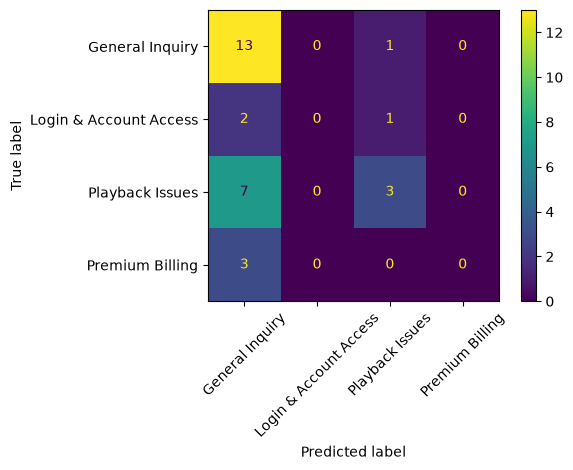

In [9]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(
    model,
    X_test,
    y_test,
    xticks_rotation=45
)

plt.tight_layout()
plt.savefig("../results/confusion_matrix.png", dpi=300)
plt.show()

In [10]:
import joblib

joblib.dump(model, "../results/intent_model.pkl")
print("Model saved!")

Model saved!
